In [6]:
import os
import osmnx as ox
import networkx as nx
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely import wkt
import math
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Defining the map boundaries for Seattle Downtown Area
north, east, south, west = 47.62425802431359, -122.35919327219091, 47.596252480947555, -122.31765250756945
# Downloading the map as a graph object
graph = ox.graph_from_bbox(bbox=(north, south, east, west), retain_all=True, network_type = 'walk')

In [8]:
# Retrieve nodes and edges geoDataFrame from MultiDiGraph graph
nodes, edges = ox.graph_to_gdfs(graph)
nodes.to_csv(r'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\data\nodes.csv', index=True)
nodes.head()
edges.to_csv(r'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\data\edges.csv', index=True)
edges.head()

,,,osmid,highway,name,ref,oneway,reversed,length,geometry,maxspeed,lanes,width,bridge,service,tunnel,access
u,v,key,,,,,,,,,,,,,,,
21627702,12699412720,0,298359272,track,Wimbachweg,AV 411;AV 421,False,False,51.773333,"LINESTRING (12.91907 47.59623, 12.91883 47.596...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
46234084,3466143410,0,5812656,service,NaN,NaN,False,True,58.156090,"LINESTRING (-112.02062 47.59625, -112.02044 47...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
48820759,10296450013,0,5935376,unclassified,Peha Road East,NaN,False,False,203.799376,"LINESTRING (-118.90692 47.59622, -118.90964 47...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
66211812,2019570459,0,203793418,track,Tauplitzalm Plateauweg,NaN,False,False,9.084024,"LINESTRING (13.99526 47.59621, 13.99514 47.59622)",20,NaN,NaN,NaN,NaN,NaN,NaN
183004933,1151639239,0,32354599,unclassified,Höhenreute,NaN,False,True,30.205180,"LINESTRING (9.71611 47.59623, 9.71571 47.59623)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
import ast
# Read the modified edges CSV file
adjusted_edges = pd.read_csv(r'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\data\new_updated_edges_2 1.csv')

adjusted_edges['image_list'] = adjusted_edges['image_list'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

adjusted_edges.to_csv(r'C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\data\new_updated_edges_2 1.csv', index = False)
# Convert the 'geometry' column from WKT back to geometric objects
adjusted_edges['geometry'] = adjusted_edges['geometry'].apply(wkt.loads)

# add travel time to modified_edges
# all distances are in meters
# travel speed is 4800 meters/hour or 2.98 miles/hour
default_speed = 4800
# travel time is meters per hour
adjusted_edges['travel_time'] = (adjusted_edges['length'] / default_speed) * 60
# Convert the DataFrame back to a GeoDataFrame
modified_edges = gpd.GeoDataFrame(adjusted_edges, crs='epsg:4326')

# Assuming 'modified_edges' has 'u', 'v', and 'key' columns
modified_edges.set_index(['u', 'v', 'key'], inplace=True)

modified_edges.head()


Unnamed: 0                   osmid       highway  \
u        v           key                                                     
29938143 321336630   0             0                29214061       footway   
30079057 10653494673 0             1                22927964       primary   
         10653494674 0             2               169473535  unclassified   
         10653494670 0             3               428237363     secondary   
         10653494669 0             4  [623957704, 393047812]     secondary   

                          oneway reversed  length lanes                  name  \
u        v           key                                                        
29938143 321336630   0     False    FALSE  13.325   NaN                   NaN   
30079057 10653494673 0     False    FALSE   7.305     4        Stewart Street   
         10653494674 0     False    FALSE   6.057     1           John Street   
         10653494670 0     False     TRUE   5.404     4  Eastlake Avenue East   
         10653494669 0     False     TRUE  14.680     2  Eastlake Avenue East   

                         maxspeed  \
u        v           key            
29938143 321336630   0        NaN   
30079057 10653494673 0     25 mph   
         10653494674 0     20 mph   
         10653494670 0     25 mph   
         10653494669 0     25 mph   

                                                                   geometry  \
u        v           key                                                      
29938143 321336630   0    LINESTRING (-122.35782 47.61696, -122.35796 47...   
30079057 10653494673 0    LINESTRING (-122.32913 47.61969, -122.32919 47...   
         10653494674 0    LINESTRING (-122.32913 47.61969, -122.32921 47...   
         10653494670 0    LINESTRING (-122.32913 47.61969, -122.32913 47...   
         10653494669 0    LINESTRING (-122.32913 47.61969, -122.32912 47...   

                          ...        P46        P47        P48        P49  \
u        v           key  ...                                               
29938143 321336630   0    ...  21.813179  23.285968  22.586676  19.843121   
30079057 10653494673 0    ...  21.924886  23.537389  23.572149  22.373323   
         10653494674 0    ...  21.655738  23.102459  22.908377  21.833847   
         10653494670 0    ...  22.300113  23.758796  23.431641  22.150952   
         10653494669 0    ...  21.671901  22.019949  22.836645  22.359774   

                                P50 CLIP Score OPENAI Score  \
u        v           key                                      
29938143 321336630   0    21.454141   6.619186     7.500000   
30079057 10653494673 0    21.750458   6.719633     5.000000   
         10653494674 0    20.826135   7.035991     6.000000   
         10653494670 0    21.563751   7.143870     6.500000   
         10653494669 0    21.994142   6.667440     4.333333   

                         adjusted_CLIP_score adjusted_OPENAI_score travel_time  
u        v           key                                                        
29938143 321336630   0              3.380814              4.380814    0.166563  
30079057 10653494673 0              3.280367              4.280367    0.091313  
         10653494674 0              2.964009              3.964009    0.075713  
         10653494670 0              2.856130              3.856130    0.067550  
         10653494669 0              3.332560              4.332560    0.183500  

[5 rows x 130 columns]

In [10]:
# Create MultiDiGraph using nodes and modified_edges GeoDataFrames
# G = ox.utils_graph.graph_from_gdfs(nodes, modified_edges)

In [11]:
# Create network of walkability in Seattle
# This graph (G_2),  used to find the destination and origin, must be seperate
## from the other graph, used to find the paths in between (G_clip and G_openai)
G_2 = ox.graph_from_place('Seattle, Washington, USA', network_type='walk')


In [12]:
# Ask the user for the origin and destination locations
origin = input("Enter the origin location: ")
destination = input("Enter the destination location: ")

# origin_point = (33.787201, -84.405076)
# origin = "Oregon Apartments, Seattle"

# Geocode the locations
origin_point = ox.geocoder.geocode(origin)
destination_point = ox.geocoder.geocode(destination)

# Get the nearest nodes to the locations
origin_node = ox.nearest_nodes(G_2, origin_point[1], origin_point[0])
destination_node = ox.nearest_nodes(G_2, destination_point[1], destination_point[0])

# Print the closest node IDs to the origin and destination points
print("Origin node:\t ", origin_node, "\t", origin)
print("Destination node:", destination_node, "\t", destination)

Origin node:	  3605547983 	 Oregon Apartments
Destination node: 10707035583 	 Pike Place Market


In [13]:
# Create MultiDiGraph using nodes and modified_edges GeoDataFrames
G_clip = ox.utils_graph.graph_from_gdfs(nodes, modified_edges)

# Find paths that has the lowest adjusted_score, which is the highest score
# paths = list(ox.routing.k_shortest_paths(G, origin_node, destination_node, 100, weight = 'adjusted_score'))
## k =100, 3 paths, 
## k=300, 8 paths, 
## k=400, 10 paths
paths_clip = list(ox.k_shortest_paths(G_clip, origin_node, destination_node, 100, weight = 'adjusted_CLIP_score'))
paths_clip

AttributeError: module 'osmnx' has no attribute 'utils_graph'

In [ ]:
# Create MultiDiGraph using nodes and modified_edges GeoDataFrames
G_openai = ox.utils_graph.graph_from_gdfs(nodes, modified_edges)

# Find paths that has the lowest adjusted_score, which is the highest score
# paths = list(ox.routing.k_shortest_paths(G, origin_node, destination_node, 100, weight = 'adjusted_score'))
## k =100, 3 paths, 
## k=300, 8 paths, 
## k=400, 10 paths
paths_openai = list(ox.k_shortest_paths(G_openai, origin_node, destination_node, 100, weight = 'adjusted_OPENAI_score'))
paths_openai

[[10927951371,
  6187052091,
  10917531117,
  53070534,
  10917531115,
  699288173,
  53200379,
  10917529400,
  10593082278,
  10713577980,
  53119471,
  10713577981,
  5321173255,
  5321173224,
  5321189731,
  10724964236,
  53045786,
  10724964274,
  53160858,
  10724964272,
  10742616287,
  3400818396,
  10742616286,
  53142141,
  8549730070,
  10745162561,
  5321305056,
  5321305055,
  10745004216,
  53207667,
  10745004219,
  10744649523,
  53207665,
  10744649526,
  10744555681,
  2053744124,
  10744555683,
  289461282,
  10744555685,
  10744496287,
  289461281,
  10744496271,
  5321357392,
  10744496258],
 [10927951371,
  6187052091,
  10917531117,
  53070534,
  10917531115,
  699288173,
  53200379,
  10917529400,
  10593082278,
  10713577980,
  53119471,
  10713577981,
  5321173255,
  5321173224,
  5321189731,
  10724964236,
  53045786,
  10724964274,
  53160858,
  10724964272,
  10742616287,
  3400818396,
  10742616286,
  53142141,
  8549730070,
  10745162561,
  5321305056,
 

There is an error with 72 edges that have a missing adjusted OpenAI and adjusted CLIP scores.
To fix this the mode of both scores is used as a replacement. This replacement value is the
same one used for edges without an image, after all the duplicate and indoor images were removed. 

In [ ]:
from collections import Counter

# Step 1: Get all existing adjusted_OPENAI_score values
adjusted_scores_openai = [
    d['adjusted_OPENAI_score']
    for _, _, d in G_openai.edges(data=True)
    if 'adjusted_OPENAI_score' in d
]

adjusted_scores_clip = [
    d['adjusted_CLIP_score']
    for _, _, d in G_clip.edges(data=True)
    if 'adjusted_CLIP_score' in d
]

# Step 2: Compute the mode (most common score)
score_counts_openai = Counter(adjusted_scores_openai)
mode_score_openai = score_counts_openai.most_common(1)[0][0]

score_counts_clip = Counter(adjusted_scores_clip)
mode_score_clip = score_counts_clip.most_common(1)[0][0]

# Step 3: Fix missing scores and count and replace them
fixed_count_openai = 0
for u, v, d in G_openai.edges(data=True):
    if 'adjusted_OPENAI_score' not in d:
        d['adjusted_OPENAI_score'] = mode_score_openai
        fixed_count_openai += 1

fixed_count_clip = 0
for u, v, d in G_clip.edges(data=True):
    if 'adjusted_CLIP_score' not in d:
        d['adjusted_CLIP_score'] = mode_score_clip
        fixed_count_clip += 1

print(f"OpenAI: Fixed {fixed_count_openai} edges by assigning the mode score: {mode_score_openai}")
print(f"CLIP: Fixed {fixed_count_clip} edges by assigning the mode score: {mode_score_clip}")

OpenAI: Fixed 72 edges by assigning the mode score: 5.026504672587244
CLIP: Fixed 72 edges by assigning the mode score: 4.026504672587244


In [ ]:
# print(dir(ox))

In [ ]:
# Construct of list lines from a list of nodes
def node_list_to_path(G, node_list, score_method):
    """
    Given a list of nodes, return a list of lines that together
    follow the path
    defined by the list of nodes.
    Parameters
    ----------
    G : networkx multidigraph
    route : list
        the route as a list of nodes
    Returns
    -------
    lines : list of lines given as pairs ( (x_start, y_start),
    (x_stop, y_stop) )
    """
    edge_nodes = list(zip(node_list[:-1], node_list[1:]))
    lines = []
    for u, v in edge_nodes:
        # if there are parallel edges, select the shortest in length
        data = min(G.get_edge_data(u, v).values(),
                   key=lambda x: x[score_method])
        # if it has a geometry attribute
        if 'geometry' in data:
            # add them to the list of lines to plot
            xs, ys = data['geometry'].xy
            lines.append(list(zip(xs, ys)))
        else:
            # if it doesn't have a geometry attribute,
            # then the edge is a straight line from node to node
            x1 = G.nodes[u]['x']
            y1 = G.nodes[u]['y']
            x2 = G.nodes[v]['x']
            y2 = G.nodes[v]['y']
            line = [(x1, y1), (x2, y2)]
            lines.append(line)
    return lines

In [ ]:
# Find the coordinates of for series of points along the path
def prepare_path_coordinates(G, path, score_method):
    lines = node_list_to_path(G, path, score_method)
    lat, long = [], []
    for line in lines:
        for x, y in line:
            long.append(x)
            lat.append(y)
    return lat, long

# Select specific paths based on their indices
paths_to_plot_clip = [paths_clip[i] for i in [0, 40, 80]]
paths_to_plot_openai = [paths_openai[i] for i in [0, 40, 80]]


In [ ]:
# Retrieve the original score, from the adjusted score
def retrieve_score_clip(adjusted_edges, adjusted_score):
    score = adjusted_edges[adjusted_edges['adjusted_CLIP_score'] == adjusted_score]['CLIP Score'].iloc[0]
    return score


In [ ]:
# Retrieve the original score, from the adjusted score
def retrieve_score_openai(adjusted_edges, adjusted_score):
    score = adjusted_edges[adjusted_edges['adjusted_OPENAI_score'] == adjusted_score]['OPENAI Score'].iloc[0]
    return score

In [ ]:
# Compute CLIP score for a path
def calculate_path_clip_score(G, path):
    # score = 0
    # for i, node in enumerate(path[:-1]):
    #    adjusted_score = nx.shortest_path_length(G, node, path[i + 1], weight='adjusted_CLIP_score')
    #    score += retrieve_score_clip(adjusted_edges, adjusted_score)
    # return score
    score = 0
    
    for i, node in enumerate(path[:-1]):
        try:
            # Calculate the adjusted score between two nodes
            adjusted_score = nx.shortest_path_length(G, node, path[i + 1], weight='adjusted_CLIP_score')

            # Debugging: Print the adjusted score
            #print(f"Adjusted score for nodes {node} -> {path[i + 1]}: {adjusted_score}")

            # Attempt to retrieve the score based on adjusted score
            retrieved_score = retrieve_score_clip(adjusted_edges, adjusted_score)

            # Debugging: Print the retrieved score
            #print(f"Retrieved score: {retrieved_score}")

            # Add the retrieved score to the total
            score += retrieved_score
        
        except KeyError as e:
            #print(f"KeyError: {e} - Could not find a valid key in adjusted_edges for {node} -> {path[i + 1]}")
            # Handle KeyError by skipping or assigning a default value
            continue
        
        except IndexError as e:
            #print(f"IndexError: {e} - Issue retrieving score for {node} -> {path[i + 1]} with adjusted_score: {adjusted_score}")
            # Handle IndexError by skipping or assigning a default value
            continue
        
        except Exception as e:
            #print(f"Unexpected error: {e}")
            continue
    return score    


In [ ]:
# Compute OPENAI score for a path
def calculate_path_openai_score(G, path):
    score = 0
    for i, node in enumerate(path[:-1]):
        try:
            # Calculate the adjusted score between two nodes
            adjusted_score = nx.shortest_path_length(G, node, path[i + 1], weight='adjusted_OPENAI_score')

            # Debugging: Print the adjusted score
            #print(f"Adjusted score for nodes {node} -> {path[i + 1]}: {adjusted_score}")

            # Attempt to retrieve the score based on adjusted score
            retrieved_score = retrieve_score_openai(adjusted_edges, adjusted_score)

            # Debugging: Print the retrieved score
            #print(f"Retrieved score: {retrieved_score}")

            # Add the retrieved score to the total
            score += retrieved_score
        
        except KeyError as e:
            #print(f"KeyError: {e} - Could not find a valid key in adjusted_edges for {node} -> {path[i + 1]}")
            # Handle KeyError by skipping or assigning a default value
            continue
        
        except IndexError as e:
            #print(f"IndexError: {e} - Issue retrieving score for {node} -> {path[i + 1]} with adjusted_score: {adjusted_score}")
            # Handle IndexError by skipping or assigning a default value
            continue
        
        except Exception as e:
            #print(f"Unexpected error: {e}")
            continue

    return score

In [ ]:
# Probability list and directions
walkability_factors = [
    {"No": 1, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Paved sidewalk", "Direction": 1},
    {"No": 2, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No sidewalk", "Direction": -1},
    {"No": 3, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Continous sidewalk", "Direction": 1},
    {"No": 4, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Incomplete sidewalk", "Direction": -1},
    {"No": 5, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Smooth sidewalk", "Direction": 1},
    {"No": 6, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Cracked sidewalk", "Direction": -1},
    {"No": 7, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Wide sidewalk", "Direction": 1},
    {"No": 8, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Narrow sidewalk", "Direction": -1},
    {"No": 9, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Buffer zone between sidewalk and street", "Direction": 1},
    {"No": 10, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No buffer zone between sidewalk and street", "Direction": -1},
    {"No": 11, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No construction", "Direction": 1},
    {"No": 12, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Construction on sidewalk", "Direction": -1},
    {"No": 13, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No tents", "Direction": 1},
    {"No": 14, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Tents on sidewalk", "Direction": -1},
    {"No": 15, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No scaffolding", "Direction": 1},
    {"No": 16, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Scaffolding", "Direction": -1},
    {"No": 17, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "Streetlights", "Direction": 1},
    {"No": 18, "Index": "Safety", "Indicator": "Sidewalk", "Prompt": "No streetlights", "Direction": -1},
    {"No": 19, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Clear intersection", "Direction": 1},
    {"No": 20, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Busy intersection", "Direction": -1},
    {"No": 21, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Pedestrian crossing signal", "Direction": 1},
    {"No": 22, "Index": "Safety", "Indicator": "Intersections", "Prompt": "No pedestrian crossing signal", "Direction": -1},
    {"No": 23, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Pedestrian crosswalk", "Direction": 1},
    {"No": 24, "Index": "Safety", "Indicator": "Intersections", "Prompt": "No pedestrian crosswalk", "Direction": -1},
    {"No": 25, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Traffic light", "Direction": 1},
    {"No": 26, "Index": "Safety", "Indicator": "Intersections", "Prompt": "No traffic light", "Direction": -1},
    {"No": 27, "Index": "Safety", "Indicator": "Intersections", "Prompt": "Stop sign", "Direction": 1},
    {"No": 28, "Index": "Safety", "Indicator": "Intersections", "Prompt": "No stop sign", "Direction": -1},
    {"No": 29, "Index": "Safety", "Indicator": "Traffic", "Prompt": "One car lane", "Direction": 1},
    {"No": 30, "Index": "Safety", "Indicator": "Traffic", "Prompt": "Many car lanes", "Direction": -1},
    {"No": 31, "Index": "Safety", "Indicator": "Traffic", "Prompt": "No railroad tracks", "Direction": 1},
    {"No": 32, "Index": "Safety", "Indicator": "Traffic", "Prompt": "Railroad tracks", "Direction": -1},
    {"No": 33, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "No stairs", "Direction": 1},
    {"No": 34, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "Stairs", "Direction": -1},
    {"No": 35, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "Outdoor seating", "Direction": 1},
    {"No": 36, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "No outdoor seating", "Direction": -1},
    {"No": 37, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "Public transportation stop", "Direction": 1},
    {"No": 38, "Index": "Safety", "Indicator": "Accessibility", "Prompt": "No public transportation", "Direction": -1},
    {"No": 39, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "No trash or dumpsters", "Direction": 1},
    {"No": 40, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "Trash or dumpsters", "Direction": -1},
    {"No": 41, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "No graffiti", "Direction": 1},
    {"No": 42, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "Graffiti", "Direction": -1},
    {"No": 43, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "Populated area", "Direction": 1},
    {"No": 44, "Index": "Appeal", "Indicator": "Comfort", "Prompt": "Abandoned building", "Direction": -1},
    {"No": 45, "Index": "Appeal", "Indicator": "Nature", "Prompt": "Trees, grass, or flowers", "Direction": 1},
    {"No": 46, "Index": "Appeal", "Indicator": "Nature", "Prompt": "No trees, grass, or flowers", "Direction": -1},
    {"No": 47, "Index": "Appeal", "Indicator": "Points of Interest", "Prompt": "Recreational park or playground", "Direction": 1},
    {"No": 48, "Index": "Appeal", "Indicator": "Points of Interest", "Prompt": "No recreational park or playground", "Direction": -1},
    {"No": 49, "Index": "Appeal", "Indicator": "Points of Interest", "Prompt": "Shops or restaurants", "Direction": 1},
    {"No": 50, "Index": "Appeal", "Indicator": "Points of Interest", "Prompt": "No shops or restaurants", "Direction": -1}

]

In [ ]:
# Retrieve weighted probability, from the adjusted score
def retrieve_weighted_probabilities(adjusted_edges, adjusted_score, score_method):
    # Initialize an empty list to store probabilities
    probabilities = []
    # Iterate through each probability column P1 to P40
    for P in range(1, 51):
        # Construct the column name
        probability_column = f'P{P}'
        # Retrieve the probability for the column from the row where 'adjusted_score' matches
        #probability = adjusted_edges[adjusted_edges[score_method] == adjusted_score][probability_column].iloc[0]
        filtered_df = adjusted_edges[adjusted_edges[score_method] == adjusted_score]
        if filtered_df.empty:
            print(f"No match found for adjusted score: {adjusted_score}")
            probability = 0  # Or handle this differently
        else:
            probability = filtered_df[probability_column].iloc[0]
        # Append the retrieved probability to the list
        probabilities.append(probability)
    return probabilities

In [ ]:
def calculate_path_weighted_probabilities(G, path, score_method):
    # Initialize a list to hold the cumulative probabilities for each P1 to P50
    probabilities_list = [0] * 50  # Initialize a list of 50 zeros

    for i, node in enumerate(path[:-1]):
        # Retrieve the adjusted score for the path segment
        adjusted_score = nx.shortest_path_length(G, node, path[i + 1], weight=score_method)
        
        # Retrieve the weighted probabilities list for this segment
        segment_probabilities = retrieve_weighted_probabilities(adjusted_edges, adjusted_score, score_method)
        
        # Add each of the segment's probabilities to the cumulative weighted probabilities
        probabilities_list = [sum(x) for x in zip(probabilities_list, segment_probabilities)]
    
    # Return the probabilities list
    return probabilities_list


In [ ]:
def map_probabilities_to_prompts(top_probabilities_indices, walkability_factors):
    positive_prompts = []
    negative_prompts = []

    for idx in top_probabilities_indices:
        factor = next((item for item in walkability_factors if item['No'] == idx + 1), None)
        if factor:
            prompt = factor['Prompt']
            direction = factor['Direction']

            if direction == 1:
                positive_prompts.append(prompt)
            elif direction == -1:
                negative_prompts.append(prompt)

    # Format strings for positive and negative prompts using HTML for new lines, tabs, and adding "and" before the last prompt
    positive_str = format_prompts(positive_prompts)
    negative_str = format_prompts(negative_prompts)

    # Combine both strings, handling cases where one list may be empty, using HTML format
    combined_str = "\t\t\t\tPros: "
    if positive_prompts:
        combined_str += positive_str
    if positive_prompts and negative_prompts:
        combined_str += "<br>\t\t\t\tCons: "
    if negative_prompts:
        combined_str += negative_str

    return combined_str

# Helper function to format prompts with HTML tags, adding "and" before the last item
def format_prompts(prompts):
    if len(prompts) > 1:
        # Join all but the last prompt, add 'and' before the last prompt
        formatted_prompts = "<br>".join(['\t\t\t\t\t\t\t\t\t\t\t\t\t' + p + ',' if i else p + ',' for i, p in enumerate(prompts[:-1])])
        formatted_prompts += "<br>\t\t\t\t\t\t\t\t\t\t\t\t\tand " + prompts[-1] + '.'
    elif prompts:
        formatted_prompts = prompts[0]  # Only one prompt, just use it directly
    else:
        formatted_prompts = ''  # No prompts
    return formatted_prompts


In [ ]:
# Calculate travel time for a path
def calculate_path_travel_time(G, path):
    total_travel_time = 0
    edge_nodes = list(zip(path[:-1], path[1:]))
    for u, v in edge_nodes:
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            travel_time = edge_data[0].get('travel_time', 0)
        total_travel_time += travel_time    
    return total_travel_time



In [ ]:
# Calculate path length
def calculate_path_length(G, path):
    total_length = 0
    edge_nodes = list(zip(path[:-1], path[1:]))
    
    for u, v in edge_nodes:
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            length = edge_data[0].get('length', 0)
        total_length += length
    return total_length

In [ ]:
# Elevations of every node
# To create this file, take node.csv and get the elevation by longitude and latitude coordinate
## Elevation data can be found at this website:
## https://srtm.csi.cgiar.org/srtmdata/
node_elevation_df = pd.read_csv(r"C:\Users\vzhang\Documents\GitHub\Robotics\STARSWalkability\accesscore\data\nodes_elevation.csv")

In [ ]:
# display the slope of a path
def display_elevation_of_path(G, path, origin_node, path_number):
    file_path = r"C:\Users\garla\first-node\WalkExplorer\routing\all_images_elevation_metadata.csv"
    elevation_df = pd.read_csv(file_path)
    elevation_df.head()
    elevation_score = []
    length_dist = []
    total_length = 0
    
    origin_elev = node_elevation_df[node_elevation_df['osmid'] == origin_node]['elevation'].values
    elevation_score.append(origin_elev)
    length_dist.append(total_length)
    
    edge_nodes = list(zip(path[:-1], path[1:]))
   
    for u, v in edge_nodes:
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            # the new length is added to the total length
            length = edge_data[0].get('length', 0)
            total_length += length
            length_dist.append(total_length)
            # elevation is taken from 'V' of edges
            elev = node_elevation_df[node_elevation_df['osmid'] == v]['elevation'].values
            elevation_score.append(elev)
    
    # Plot the original elevation data 
    # Fill in the area between x-axis and elevation scores
    # baseline = min(elevation_score) - 10
    plt.figure(figsize = (15, 5))
    plt.plot(length_dist, elevation_score, marker = 'o', linestyle = '-', color = 'b')
    # plt.fill_between(length_dist, elevation_score, baseline, color='b', alpha=0.2)
    plt.xlabel("Distance of path (meters)", fontsize = 'large')
    plt.ylabel("Elevation (meters)", fontsize = 'large')
    # plt.title("Elevation of Path " + str(path_number))  
    plt.grid(True)
    plt.axis('equal') # x and y will be on the same scale
    plt.show()
    
    

In [ ]:
# Display and save the images from the path from CLIP and OPENAI scores into a csv file
def display_and_save_path_images(G, path, path_number, score_method, path_score):
    image_seq = []
    file_path = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\path_images.csv"
        
   # Prepare the image names for each edge in the path
    edge_nodes = list(zip(path[:-1], path[1:]))
    for u, v in edge_nodes:
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            image_list = edge_data[0].get('image_list', {})
            # Ensure 'image_list' is a dictionary and has at least one entry
            if isinstance(image_list, dict) and '0' in image_list:
                first_image = image_list['0']  # Get the first image (typically with key '0')
                image_name = f"{first_image}.jpg"  # Just save the first image name
                image_seq.append(image_name)
            else:
                image_seq.append('')  # If no image, append an empty string for that edge
    
   # Create a DataFrame to save path information
    df = pd.DataFrame({
        'Path_Number': [path_number],
        'Score_Method': [score_method],
        'Path_Score': [path_score],
        'Image_Sequence': [", ".join(image_seq)]  # Save the image sequence as a single string
    })

    # Check if the file exists and is not empty
    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
        df.to_csv(file_path, mode='a', header=False, index=False)  # Append without header
    else:
        df.to_csv(file_path, mode='w', header=True, index=False)  # Write with header if new file

Penalty for slope.
A path is increasing if the destination has a higher elevation than the origin, and decreasing if the destination
has a lower elevation than the origin. A penalty will only consider the increase/decrease in elevation for 
a path that is increasing/decreasing. 
1) Penalty 1: The maximum angle of elevation increase or decrease. 
    - Determined by the tangent of the difference in altitude and distance between two nodes in an edge. 
2) Penalty 2: The summation of all elevation increases/decreases greater than the previous increase/decrease
    - The difference in altitude is checked between two nodes (u,v) in an edge. 
    - The absolute value is taken, so the penalty is always positive. 
    - The last added edge (u,v) is kept track
    - If the new edge's v node has a higher(increase)/lower(decrease) elevation than the
    - - last added edge's v node, than the new edge is added to the summation and becomes
    - - the last added edge. Otherwise, the edge is skipped over.      


In [ ]:
# Penalty 1
def slope_penalty_1(G, path):
    edge_nodes = list(zip(path[:-1], path[1:]))
    elevation_angles = []
    # the new length is added to the total length
    for u, v in edge_nodes:
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            distance = edge_data[0].get('length', 0)
            elevation_u = node_elevation_df[node_elevation_df['osmid'] == u]['elevation'].values
            elevation_v = node_elevation_df[node_elevation_df['osmid'] == v]['elevation'].values
            elevation_diff = elevation_v - elevation_u
            angle_rad = math.atan(elevation_diff / distance)
            angle = math.degrees(angle_rad)
            elevation_angles.append(angle)
    print(f"Penaly 1: {max(elevation_angles)}")        
    return max(elevation_angles)
    

In [ ]:
# Penalty 2
def slope_penalty_2(G, path, origin_node, destination_node):
    edge_nodes = list(zip(path[:-1], path[1:]))
    penalty_dict = {}
    
    last_included_elevation = None
    is_increasing = None
    
    origin_node_elevation = node_elevation_df[node_elevation_df['osmid'] == origin_node]['elevation'].values.item()
    destination_node_elevation = node_elevation_df[node_elevation_df['osmid'] == destination_node]['elevation'].values.item()
    
    if(destination_node_elevation > origin_node_elevation):
        is_increasing = True
    else:
        is_increasing = False
    
    for i, (u, v) in enumerate(edge_nodes):
        edge_data = G.get_edge_data(u, v)
        if edge_data and 0 in edge_data:
            elevation_u = node_elevation_df[node_elevation_df['osmid'] == u]['elevation'].values.item()
            elevation_v = node_elevation_df[node_elevation_df['osmid'] == v]['elevation'].values.item()
            elevation_diff = abs(elevation_v - elevation_u)
            
            # Initialize the trend
            if i == 0:
                is_increasing = elevation_v > elevation_u
                last_included_elevation = elevation_u
            
            # Determine if the current edge should be included
            if is_increasing:
                if elevation_v > last_included_elevation:
                    penalty_dict[(u, v)] = elevation_diff
                    last_included_elevation = elevation_v
            else:
                if elevation_v < last_included_elevation:
                    penalty_dict[(u, v)] = elevation_diff
                    last_included_elevation = elevation_v
    
    # Calculate and return the sum of the values in penalty_dict
    total_penalty = sum(penalty_dict.values())
    print(f"Penaly 2: {total_penalty}") 
    return total_penalty

Map graphs of all OpenAI and CLIP model paths

In [ ]:
# Plot 3 paths from CLIP model, on seperate graphs, and display changes in elevation 

def plot_multiple_paths_with_scores_factors_clip(G, paths, origin_point, destination_point, colors, output_dir):
    # Calculate and sort paths by score
    paths_with_scores = [{'path': path, 'CLIP Score': calculate_path_clip_score(G, path),
                          'probabilities': calculate_path_weighted_probabilities(G, path, 'adjusted_CLIP_score')} for path in paths]
    paths_sorted_by_score = sorted(paths_with_scores, key=lambda x: x['CLIP Score'], reverse=True)
    top_paths = [paths_sorted_by_score[i] for i in [0, 40, 80]]

    # Determine the number of top paths to select (limit to the length of the sorted list)
    num_top_paths = min(10, len(paths_sorted_by_score))  # Get at most 10 paths

    # Create a list of indices to access
    indices = list(range(0, len(paths_sorted_by_score), 40))[:num_top_paths]

    # Safely access the top paths
    top_paths = [paths_sorted_by_score[i] for i in indices if i < len(paths_sorted_by_score)]

    path_number = 1
    for i, path_info in enumerate(top_paths):
        path, color = path_info['path'], colors[i]
        lat, long = prepare_path_coordinates(G, path, 'adjusted_CLIP_score')
        path_score = path_info['CLIP Score']
        travel_time = calculate_path_travel_time(G, path)
        path_length = calculate_path_length(G, path)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        display_and_save_path_images(G, path, path_number, 'CLIP', path_score)
        display_elevation_of_path(G, path, origin_node, path_number)
        
        fig = go.Figure()

        # Plot path
        fig.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long,
            lat=lat,
            line=dict(width=5, color=color),
            name=f"Path {path_number}: CLIP Score {path_score:.2f}<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

        # Add origin and destination markers
        fig.add_trace(go.Scattermapbox(
            name="Source",
            mode="markers",
            lon=[origin_point[1]],
            lat=[origin_point[0]],
            marker={'size': 30, 'color': "red"}))

        fig.add_trace(go.Scattermapbox(
            name="Destination",
            mode="markers",
            lon=[destination_point[1]],
            lat=[destination_point[0]],
            marker={'size': 30, 'color': 'green'}))

        # Configure map appearance
        lat_center = np.mean([origin_point[0], destination_point[0]])
        long_center = np.mean([origin_point[1], destination_point[1]])
        fig.update_layout(
            mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
            margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
            width=1400, height=1200
        )

        # Save the figure
        file_path = os.path.join(output_dir, f"clip_output_path_{path_number}.png")
        fig.write_image(file_path)
        fig.show()

        path_number += 1



In [ ]:
# Plot 3 paths from CLIP model with penalties, on one graph

def plot_multiple_paths_with_scores_factors_clip_with_penalty(G, paths, origin_point, destination_point, colors, file_path):
    fig = go.Figure()
    
    # Calculate and sort paths by score
    paths_with_scores = [{'path': path, 'score': calculate_path_clip_score(G, path),
                          'probabilities': calculate_path_weighted_probabilities(G, path, 'adjusted_CLIP_score')} for path in paths]
    paths_sorted_by_score = sorted(paths_with_scores, key=lambda x: x['score'], reverse=True)
    top_paths = [paths_sorted_by_score[i] for i in [0, 40, 80]]

    # Plot each path
    path_number = 1
    for i, path_info in enumerate(top_paths):
        path, color = path_info['path'], colors[i]
        lat, long = prepare_path_coordinates(G, path, 'adjusted_CLIP_score')
        path_score = path_info['score']
        travel_time = calculate_path_travel_time(G, path)
        path_length = calculate_path_length(G, path)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        penalty_1 = slope_penalty_1(G, path)
        penalty_2 = slope_penalty_2(G, path, origin_node, destination_node)
        penalty = (penalty_1 + penalty_2) * 0.2
        path_score -= penalty
        path_number = path_number + 1
        
        fig.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long,
            lat=lat,
            line=dict(width=5, color=color),
            name=f"Path {i+1}: CLIP Score {path_score:.2f}<br>Penalty: {penalty:.2f} points<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

    # Add origin and destination markers
    fig.add_trace(go.Scattermapbox(
        name="Source",
        mode="markers",
        lon=[origin_point[1]],
        lat=[origin_point[0]],
        marker={'size': 30, 'color': "red"}))

    fig.add_trace(go.Scattermapbox(
        name="Destination",
        mode="markers",
        lon=[destination_point[1]],
        lat=[destination_point[0]],
        marker={'size': 30, 'color': 'green'}))

    # Configure map appearance
    lat_center = np.mean([origin_point[0], destination_point[0]])
    long_center = np.mean([origin_point[1], destination_point[1]])
    fig.update_layout(
        mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
        showlegend=True,
        margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
        width=1400, height=1200
    )

    # Save and display the figure
    fig.write_image(file_path)
    fig.show()

In [ ]:
# Plot 3 paths from OPENAI scores, on seperate graphs, and display changes in elevation
def plot_multiple_paths_with_scores_factors_openai(G, paths, origin_point, destination_point, colors, output_dir):
    # Calculate and sort paths by score
    paths_with_scores = [{'path': path, 'OPENAI Score': calculate_path_openai_score(G, path),
                          'probabilities': calculate_path_weighted_probabilities(G, path, 'adjusted_OPENAI_score')} for path in paths]
    paths_sorted_by_score = sorted(paths_with_scores, key=lambda x: x['OPENAI Score'], reverse=True)
    top_paths = [paths_sorted_by_score[i] for i in [0, 40, 80]]

    path_number = 1
    for i, path_info in enumerate(top_paths):
        path, color = path_info['path'], colors[i]
        lat, long = prepare_path_coordinates(G, path, 'adjusted_OPENAI_score')
        path_score = path_info['OPENAI Score']
        travel_time = calculate_path_travel_time(G, path)
        path_length = calculate_path_length(G, path)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        display_and_save_path_images(G, path, path_number, 'OPENAI', path_score)
        display_elevation_of_path(G, path, origin_node, path_number)
        
        fig = go.Figure()

        # Plot path
        fig.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long,
            lat=lat,
            line=dict(width=5, color=color),
            name=f"Path {path_number}: OPENAI Score {path_score:.2f}<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

        # Add origin and destination markers
        fig.add_trace(go.Scattermapbox(
            name="Source",
            mode="markers",
            lon=[origin_point[1]],
            lat=[origin_point[0]],
            marker={'size': 30, 'color': "red"}))

        fig.add_trace(go.Scattermapbox(
            name="Destination",
            mode="markers",
            lon=[destination_point[1]],
            lat=[destination_point[0]],
            marker={'size': 30, 'color': 'green'}))

        # Configure map appearance
        lat_center = np.mean([origin_point[0], destination_point[0]])
        long_center = np.mean([origin_point[1], destination_point[1]])
        fig.update_layout(
            mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
            margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
            width=1400, height=1200
        )

        # Save the figure
        file_path = os.path.join(output_dir, f"openai_output_path_{path_number}.png")
        fig.write_image(file_path)
        fig.show()

        path_number += 1


In [ ]:
# Plot 3 paths from OPENAI scores with penalties, on one graph

def plot_multiple_paths_with_scores_factors_openai_with_penalty(G, paths, origin_point, destination_point, colors, file_path):
    fig = go.Figure()
    
    # Calculate and sort paths by score
    paths_with_scores = [{'path': path, 'score': calculate_path_openai_score(G, path),
                          'probabilities': calculate_path_weighted_probabilities(G, path, 'adjusted_OPENAI_score')} for path in paths]
    paths_sorted_by_score = sorted(paths_with_scores, key=lambda x: x['score'], reverse=True)
    top_paths = [paths_sorted_by_score[i] for i in [0, 40, 80]]

    # Plot each path
    path_number = 1
    for i, path_info in enumerate(top_paths):
        path, color = path_info['path'], colors[i]
        lat, long = prepare_path_coordinates(G, path, 'adjusted_OPENAI_score')
        path_score = path_info['score']
        travel_time = calculate_path_travel_time(G, path)
        path_length = calculate_path_length(G, path)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        penalty_1 = slope_penalty_1(G, path)
        penalty_2 = slope_penalty_2(G, path, origin_node, destination_node)
        penalty = (penalty_1 + penalty_2) * 0.2
        path_score -= penalty
        path_number = path_number + 1
        
        fig.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long,
            lat=lat,
            line=dict(width=5, color=color),
            name=f"Path {i+1}: OPENAI Score {path_score:.2f}<br>Penalty: {penalty:.2f} points<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

    # Add origin and destination markers
    fig.add_trace(go.Scattermapbox(
        name="Source",
        mode="markers",
        lon=[origin_point[1]],
        lat=[origin_point[0]],
        marker={'size': 30, 'color': "red"}))

    fig.add_trace(go.Scattermapbox(
        name="Destination",
        mode="markers",
        lon=[destination_point[1]],
        lat=[destination_point[0]],
        marker={'size': 30, 'color': 'green'}))

    # Configure map appearance
    lat_center = np.mean([origin_point[0], destination_point[0]])
    long_center = np.mean([origin_point[1], destination_point[1]])
    fig.update_layout(
        mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
        showlegend=True,
        margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
        width=1400, height=1200
    )

    # Save and display the figure
    fig.write_image(file_path)
    fig.show()

In [ ]:
# Compare the top 3 best paths from OpenAI and the CLIP model, in 6 separate graphs
def plot_top_3_paths_both_models(G_clip, paths_clip, G_openai, paths_openai, origin_point, destination_point, top_file_paths):
    # Get the top 3 paths based on score for CLIP model
    clip_paths_with_scores = [{'path': path_c, 'score': calculate_path_clip_score(G_clip, path_c),
                               'probabilities': calculate_path_weighted_probabilities(G_clip, path_c, 'adjusted_CLIP_score')} for path_c in paths_clip]
    paths_sorted_by_clip_score = sorted(clip_paths_with_scores, key=lambda x: x['score'], reverse=True)
    top_clip_paths = paths_sorted_by_clip_score[:3]  # Top 5 CLIP paths

    # Get the top 3 paths based on score for OpenAI model
    openai_paths_with_scores = [{'path': path_ai, 'score': calculate_path_openai_score(G_openai, path_ai),
                                 'probabilities': calculate_path_weighted_probabilities(G_openai, path_ai, 'adjusted_OPENAI_score')} for path_ai in paths_openai]
    paths_sorted_by_openai_score = sorted(openai_paths_with_scores, key=lambda x: x['score'], reverse=True)
    top_openai_paths = paths_sorted_by_openai_score[:3]  # Top 5 OpenAI paths

    # Loop over the top 5 paths and create one graph for each
    for i in range(3):
        # CLIP Path Plot
        fig_clip = go.Figure()
        path_info = top_clip_paths[i]
        path_c = top_clip_paths[i]['path']
        clip_score = top_clip_paths[i]['score']
        lat_clip, long_clip = prepare_path_coordinates(G_clip, path_c, 'adjusted_CLIP_score')
        travel_time = calculate_path_travel_time(G_clip, path_c)
        path_length = calculate_path_length(G_clip, path_c)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        penalty_1 = slope_penalty_1(G_clip, path_c)
        penalty_2 = slope_penalty_2(G_clip, path_c, origin_node, destination_node)
        penalty = (penalty_1 + penalty_2) * 0.2
        clip_score -= penalty
        
        fig_clip.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long_clip,
            lat=lat_clip,
            line=dict(width=5, color='blue'),
            name=f"Path {i+1}: CLIP Score {clip_score:.2f}<br>Penalty: {penalty:.2f} points<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

        # Add origin and destination markers for CLIP
        fig_clip.add_trace(go.Scattermapbox(
            name="Source",
            mode="markers",
            lon=[origin_point[1]],
            lat=[origin_point[0]],
            marker={'size': 10, 'color': "red"}
        ))

        fig_clip.add_trace(go.Scattermapbox(
            name="Destination",
            mode="markers",
            lon=[destination_point[1]],
            lat=[destination_point[0]],
            marker={'size': 10, 'color': 'green'}
        ))

        # Configure map appearance for CLIP
        lat_center = np.mean([origin_point[0], destination_point[0]])
        long_center = np.mean([origin_point[1], destination_point[1]])
        fig_clip.update_layout(
            mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
            showlegend=True,
            margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
            width=1400, height=1200
        )

        # Save and display the CLIP figure
        file_path_clip = top_file_paths[i+1] + "_clip.png"
        file_directory_clip = os.path.dirname(file_path_clip)
        if not os.path.exists(file_directory_clip):
            os.makedirs(file_directory_clip)
        fig_clip.write_image(file_path_clip)
        fig_clip.show()

        # OpenAI Path Plot
        fig_openai = go.Figure()
        path_info = top_openai_paths[i]
        path_ai = top_openai_paths[i]['path']
        openai_score = top_openai_paths[i]['score']
        lat_openai, long_openai = prepare_path_coordinates(G_openai, path_ai, 'adjusted_OPENAI_score')
        travel_time = calculate_path_travel_time(G_openai, path_ai)
        path_length = calculate_path_length(G_openai, path_ai)
        prompts_text = map_probabilities_to_prompts(sorted(range(len(path_info['probabilities'])), key=lambda k: path_info['probabilities'][k], reverse=True)[:10], walkability_factors)
        penalty_1 = slope_penalty_1(G_openai, path_ai)
        penalty_2 = slope_penalty_2(G_openai, path_ai, origin_node, destination_node)
        penalty = (penalty_1 + penalty_2) * 0.2
        openai_score -= penalty
        
        
        fig_openai.add_trace(go.Scattermapbox(
            mode="lines",
            lon=long_openai,
            lat=lat_openai,
            line=dict(width=5, color='brown'),
            name=f"Path {i+1}: OPENAI Score {openai_score:.2f}<br>Penalty: {penalty:.2f} points<br>Travel Time: {travel_time:.2f} minutes<br>Path Length: {path_length:.2f} meters<br>{prompts_text}",
            showlegend=True
        ))

        # Add origin and destination markers for OpenAI
        fig_openai.add_trace(go.Scattermapbox(
            name="Source",
            mode="markers",
            lon=[origin_point[1]],
            lat=[origin_point[0]],
            marker={'size': 10, 'color': "red"}
        ))

        fig_openai.add_trace(go.Scattermapbox(
            name="Destination",
            mode="markers",
            lon=[destination_point[1]],
            lat=[destination_point[0]],
            marker={'size': 10, 'color': 'green'}
        ))

        # Configure map appearance for OpenAI
        fig_openai.update_layout(
            mapbox={'style': "open-street-map", 'center': {'lat': lat_center, 'lon': long_center}, 'zoom': 14},
            showlegend=True,
            margin={'l': 0, 't': 0, 'b': 0, 'r': 0},
            width=1400, height=1200
        )

        # Save and display the OpenAI figure
        file_path_openai = top_file_paths[i+1] + "_openai.png"
        file_directory_openai = os.path.dirname(file_path_openai)
        if not os.path.exists(file_directory_openai):
            os.makedirs(file_directory_openai)
        fig_openai.write_image(file_path_openai)
        fig_openai.show()

In [ ]:
# Assuming paths_to_plot contains the paths you want to plot
colors = ['blue', 'red', 'purple', 'gold', 'black', 'green', 'yellow', 'orange', 'brown', 'cyan']

# Define file path for the output image
file_path_1 = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\all_paths_1.png"
file_path_2 = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\all_paths_2.png"
file_path_3 = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\all_paths_3.png"

# File paths to compare the top 5 paths from OpenAI and CLIP models
top_file_paths = {
    1: r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\top_path_1",
    2: r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\top_path_2",
    3: r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\top_path_3",
    4: r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\top_path_4",
    5: r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3\top_path_5"
}

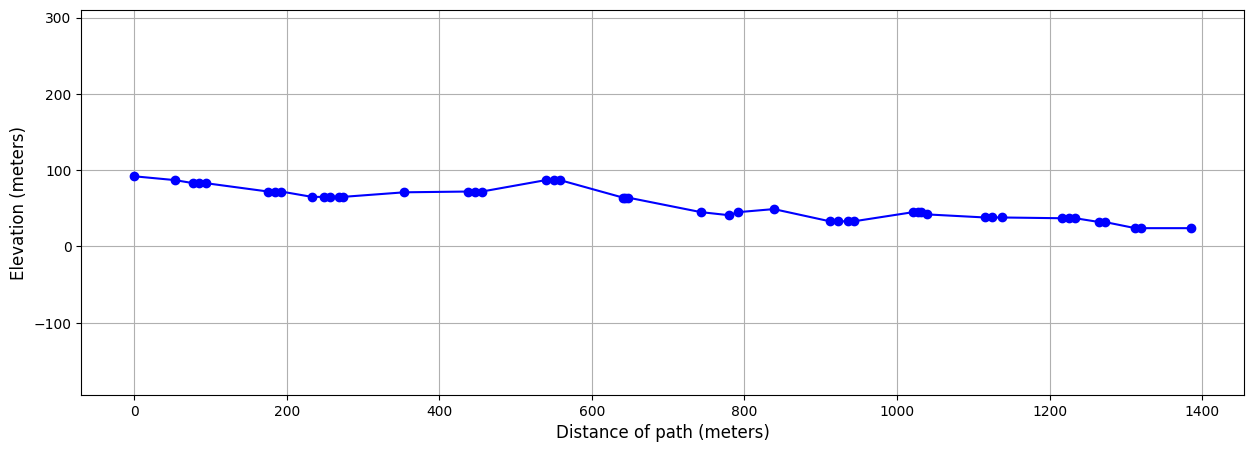

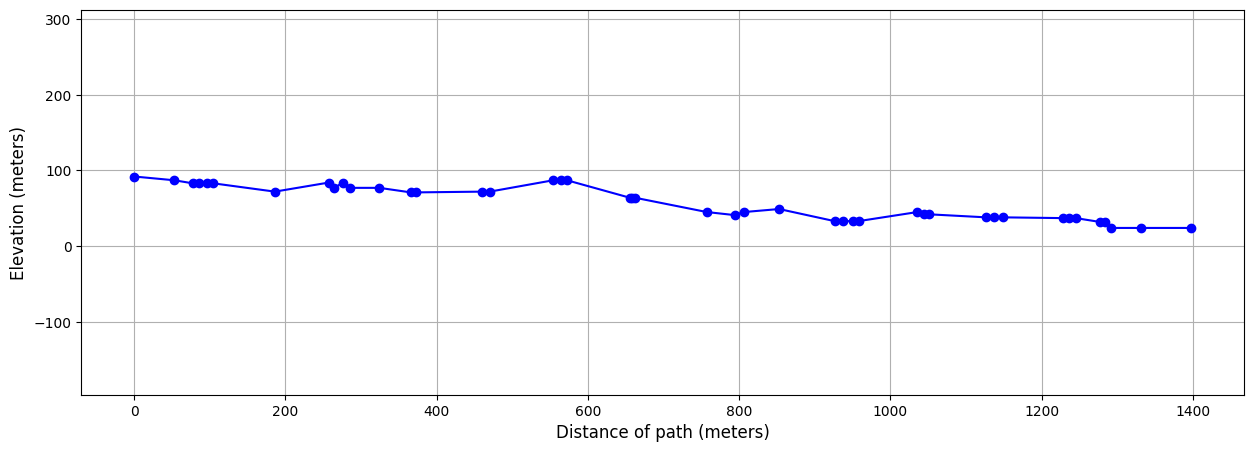

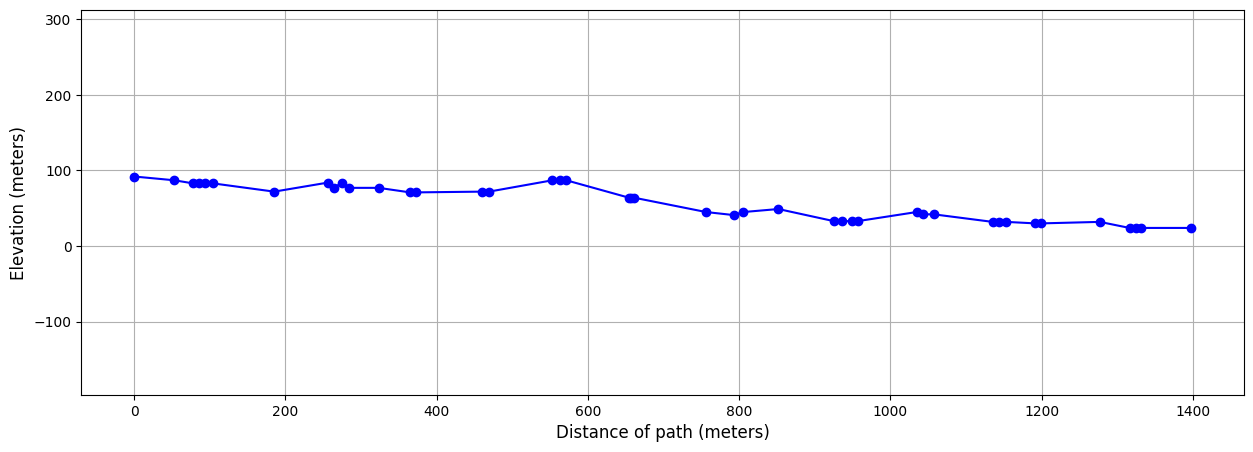

In [ ]:
# Plot 3 paths from CLIP model, on seperate graphs, and display changes in elevation

output_dir = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3"

plot_multiple_paths_with_scores_factors_clip(
    G_clip, paths_clip, origin_point, destination_point, colors, output_dir)


In [ ]:

# Plot 3 paths from CLIP model with penalties, on one graph
plot_multiple_paths_with_scores_factors_clip_with_penalty(
    G_clip, paths_clip, origin_point, destination_point, colors, file_path_1)


Penaly 1: 17.80876009041422
Penaly 2: 102
Penaly 1: 31.205214848750366
Penaly 2: 101
Penaly 1: 31.205214848750366
Penaly 2: 108


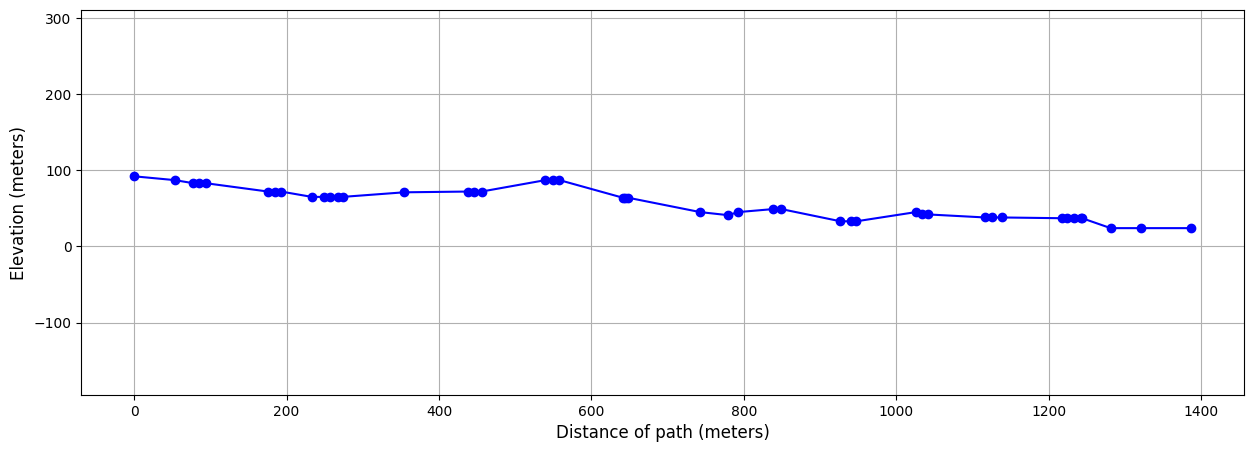

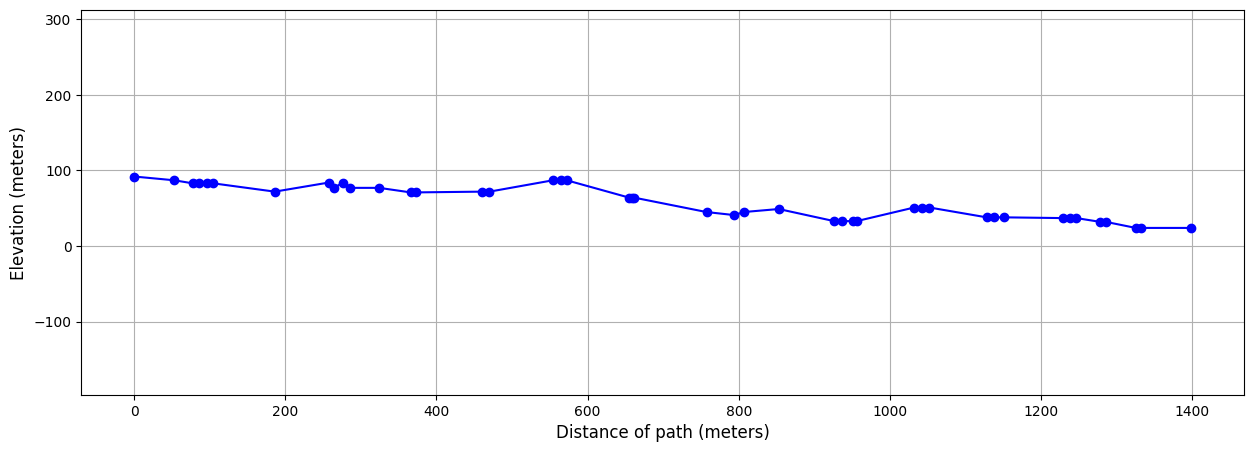

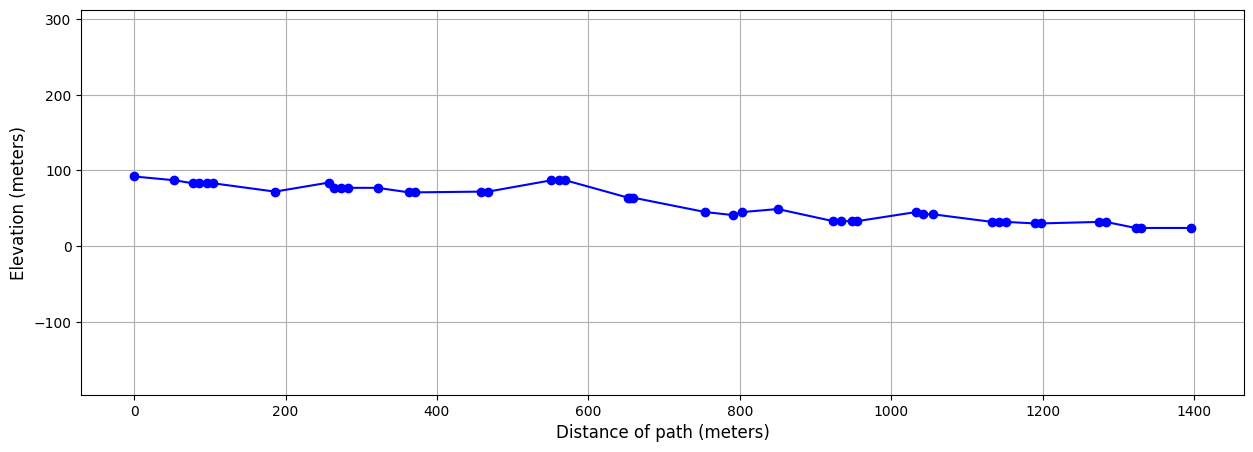

In [ ]:
# Plot 3 paths from OPENAI scores, on seperate graphs, and display changes in elevation

output_dir = r"C:\Users\garla\first-node\WalkExplorer\routing\data\ex3"

plot_multiple_paths_with_scores_factors_openai(
    G_openai, paths_openai, origin_point, destination_point, colors, output_dir)

In [ ]:
# Plot 3 paths from OPENAI scores with penalties, on one graph
plot_multiple_paths_with_scores_factors_openai_with_penalty(
    G_openai, paths_openai, origin_point, destination_point, colors, file_path_2)

Penaly 1: 17.80876009041422
Penaly 2: 102
Penaly 1: 31.205214848750366
Penaly 2: 101
Penaly 1: 17.80876009041422
Penaly 2: 108


In [ ]:
# Display top 3 paths from OPENAI and CLIP model on 6 seperate graphs
plot_top_3_paths_both_models(
    G_clip, paths_clip, G_openai, paths_openai, origin_point, destination_point, top_file_paths)

Penaly 1: 17.80876009041422
Penaly 2: 102


Penaly 1: 17.80876009041422
Penaly 2: 102


Penaly 1: 17.80876009041422
Penaly 2: 102


Penaly 1: 17.80876009041422
Penaly 2: 102


Penaly 1: 17.80876009041422
Penaly 2: 102


Penaly 1: 17.80876009041422
Penaly 2: 102
